# 2. Preprocesamiento + Modelado con Pipelines y GridSearchCV


## 2.1 Importación de librerías

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import joblib
import os

# Scikit-learn — preprocesamiento
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Scikit-learn — partición y validación
from sklearn.model_selection import (
    train_test_split, GridSearchCV,
    StratifiedKFold, cross_val_score, ParameterGrid
)

# Scikit-learn — modelos y métricas
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, f1_score,
    precision_score, recall_score, accuracy_score
)

# Boosting
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2.2 Carga del dataset

Se carga el dataset limpio generado al final del notebook de EDA (`telco_churn_clean.csv`).

El dataset tiene 7 043 registros y 20 columnas (19 predictoras + `Churn`). La tasa de churn real es del 26.5% (1 869 clientes), sin valores nulos, lo que confirma que la limpieza del notebook anterior fue exitosa.

In [2]:
df = pd.read_csv('data/telco_churn_clean.csv')
print("Dataset cargado desde data/telco_churn_clean.csv")

print(f"Shape: {df.shape}")
print(f"Churn=1: {df['Churn'].sum():,}  ({df['Churn'].mean()*100:.1f}%)")
print(f"NaN totales: {df.isnull().sum().sum()}")
df.head(3)

Dataset cargado desde data/telco_churn_clean.csv
Shape: (7043, 20)
Churn=1: 1,869  (26.5%)
NaN totales: 0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


## 2.3 Separación de variables predictoras y objetivo

Se separan las variables predictoras (`X`) de la variable objetivo (`y = Churn`).
A continuación se identifican automáticamente las columnas numéricas y categóricas,
información que el `ColumnTransformer` usará para aplicar transformaciones diferenciadas.

El resultado es: 4 variables numéricas (`SeniorCitizen`, `tenure`, `MonthlyCharges`, `TotalCharges`) y 15 variables categóricas (servicios contratados, tipo de contrato, método de pago, etc.).

In [3]:
X = df.drop(columns=['Churn'])
y = df['Churn']

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()

print(f"Variables predictoras: {X.shape[1]}")
print(f"  Numéricas  ({len(num_cols)}): {num_cols}")
print(f"  Categóricas({len(cat_cols)}): {cat_cols}")


Variables predictoras: 19
  Numéricas  (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
  Categóricas(15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 2.4 División estratificada train / test

Se usa `stratify=y` para garantizar que la proporción de clases (26.5% Churn) se mantenga idéntica en los conjuntos de entrenamiento y prueba.

Resultado de la partición 80/20:
- Train: 5 634 muestras | Churn rate: 26.5%
- Test:  1 409 muestras | Churn rate: 26.5%

La estratificación funcionó correctamente: ambas particiones mantienen exactamente la misma proporción de clases que el dataset original.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("División train / test")
print(f"  Train: {X_train.shape[0]:,} muestras | Churn rate: {y_train.mean()*100:.1f}%")
print(f"  Test:  {X_test.shape[0]:,} muestras  | Churn rate: {y_test.mean()*100:.1f}%")
print(f"\nRatio de desbalance (No Churn / Churn) en train: "
      f"{(y_train==0).sum()/(y_train==1).sum():.2f}:1")

# Guardar ratio para XGBoost
NEG_POS_RATIO = round((y_train==0).sum() / (y_train==1).sum(), 2)
print(f"scale_pos_weight para XGBoost: {NEG_POS_RATIO}")

División train / test
  Train: 5,634 muestras | Churn rate: 26.5%
  Test:  1,409 muestras  | Churn rate: 26.5%

Ratio de desbalance (No Churn / Churn) en train: 2.77:1
scale_pos_weight para XGBoost: 2.77


## 2.5 Construcción del preprocesador (`ColumnTransformer`)

In [ ]:
#Transformador para variables numéricas 
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

#Transformador para variables categóricas 
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

#ColumnTransformer: une ambos transformadores 
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
], remainder='drop')

print("ColumnTransformer construido:")
print(preprocessor)

ColumnTransformer construido:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'TotalCharges']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
    

- `SimpleImputer(strategy='median')` para numéricas: la mediana es robusta ante outliers presentes en `MonthlyCharges` y `TotalCharges` (detectados en el EDA). No hubo NaN en este dataset (`NaN totales: 0`), por lo que el imputer actúa como salvaguarda en producción.
- `StandardScaler` centra (media=0) y escala (std=1) las 4 variables numéricas. Aunque los modelos de árbol no lo requieren, su inclusión no penaliza el desempeño y mantiene el pipeline compatible con cualquier estimador futuro.
- `OneHotEncoder(handle_unknown='ignore')` convierte las 15 variables categóricas en variables binarias. `handle_unknown='ignore'` asigna vector de ceros a categorías nuevas en producción, evitando errores de inferencia.
- `sparse_output=False` devuelve arrays densos, necesario para la compatibilidad con LIME (Notebook 3).

## 2.6 Definición de Pipelines y grillas de hiperparámetros

### 2.6.1 Random Forest

In [ ]:
pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(
        random_state=RANDOM_STATE,
        class_weight='balanced',   
        n_jobs=-1
    ))
])


param_grid_rf = {
    'clf__n_estimators':      [100, 200, 300],
    'clf__max_depth':         [None, 10, 20],
    'clf__min_samples_split': [2, 5, 10],      # tamaño mínimo para dividir un nodo
    'clf__min_samples_leaf':  [1, 2, 4],       # tamaño mínimo de una hoja
    'clf__max_features':      ['sqrt', 'log2'],# máximo de features por split
    'clf__bootstrap':         [True, False],   # con/sin reemplazo en el muestreo
    'clf__criterion':         ['gini', 'entropy'], # función de impureza
}

print("Pipeline Random Forest definido.")
print(f"Combinaciones de hiperparámetros: "
      f"{3*3*3*3*2*2*2} (antes de CV)")

Pipeline Random Forest definido.
Combinaciones de hiperparámetros: 648 (antes de CV)


| Hiperparámetro | Rango | Efecto |
|---|---|---|
| `n_estimators` | 100–300 | Más árboles → mayor estabilidad, mayor costo computacional |
| `max_depth` | None / 10 / 20 | `None` = árboles completos (riesgo de sobreajuste); profundidad limitada = mayor regularización |
| `min_samples_split` | 2 / 5 / 10 | Valores altos evitan divisiones con muy pocas muestras → menos sobreajuste |
| `min_samples_leaf` | 1 / 2 / 4 | Hojas con más muestras generan predicciones más suavizadas |
| `max_features` | sqrt / log2 | Reduce correlación entre árboles; `sqrt` es el estándar para clasificación |
| `bootstrap` | True / False | `True` = bagging estándar; `False` usa todo el dataset en cada árbol |
| `criterion` | gini / entropy | `gini` es más rápido; `entropy` puede ser más informativo en datasets desbalanceados |


### 2.6.2 XGBoost

In [ ]:
pipe_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', XGBClassifier(
        random_state=RANDOM_STATE,
        scale_pos_weight=NEG_POS_RATIO,  
        eval_metric='logloss',
        n_jobs=-1,
        verbosity=0
    ))
])

param_grid_xgb = {
    'clf__n_estimators':     [100, 200, 300],
    'clf__max_depth':        [3, 5, 7],
    'clf__learning_rate':    [0.01, 0.05, 0.1],
    'clf__subsample':        [0.7, 0.85, 1.0],     
    'clf__colsample_bytree': [0.7, 0.85, 1.0],     
    'clf__gamma':            [0, 0.1, 0.3],         
    'clf__min_child_weight': [1, 3, 5],             
    'clf__reg_alpha':        [0, 0.1, 0.5],         
    'clf__reg_lambda':       [1.0, 1.5, 2.0],       
}

print("Pipeline XGBoost definido.")

Pipeline XGBoost definido.


| Hiperparámetro | Rango | Efecto |
|---|---|---|
| `subsample` | 0.7–1.0 | Fracción de muestras usadas por árbol; valores < 1 previenen sobreajuste (stochastic boosting) |
| `colsample_bytree` | 0.7–1.0 | Fracción de columnas por árbol; reduce correlación entre boosters |
| `gamma` | 0–0.3 | Reducción mínima de pérdida requerida para hacer una división; actúa como regularización estructural |
| `min_child_weight` | 1–5 | Suma mínima de pesos de instancias en una hoja; valores altos → menos sobreajuste en outliers |
| `reg_alpha` | 0–0.5 | Regularización L1 (Lasso); induce esparsidad en pesos de hojas |
| `reg_lambda` | 1–2 | Regularización L2 (Ridge); estabiliza los pesos |
| `scale_pos_weight` | 2.77 | Ratio No Churn / Churn; corrige el desbalance de clases en la función de pérdida |



### 2.6.3 CatBoost

In [ ]:
pipe_cat = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', CatBoostClassifier(
        random_state=RANDOM_STATE,
        auto_class_weights='Balanced',
        verbose=0
    ))
])

param_grid_cat = {
    'clf__iterations':         [100, 200, 300],     
    'clf__depth':              [4, 6, 8],
    'clf__learning_rate':      [0.01, 0.05, 0.1],
    'clf__l2_leaf_reg':        [1, 3, 5],            
    'clf__bagging_temperature':[0.0, 0.5, 1.0],     
    'clf__border_count':       [32, 64, 128],        
    'clf__random_strength':    [1, 2, 5],           
    'clf__one_hot_max_size':   [2, 5, 10],          
    'clf__subsample':          [0.7, 0.85, 1.0],
}

print("Pipeline CatBoost definido.")

Pipeline CatBoost definido.


| Hiperparámetro | Rango | Efecto |
|---|---|---|
| `l2_leaf_reg` | 1–5 | Regularización L2 sobre los valores de las hojas; reduce varianza |
| `bagging_temperature` | 0–1 | Controla la distribución de Bayesian Bootstrap: 0 = sin bagging, 1 = bagging estándar |
| `border_count` | 32–128 | Número de bins para discretizar variables numéricas; más bins = mayor precisión y costo |
| `random_strength` | 1–5 | Añade ruido al proceso de selección de splits para reducir el sobreajuste |
| `one_hot_max_size` | 2–10 | Variables categóricas con ≤ N categorías únicas se codifican como one-hot; el resto con ordered encoding |
| `subsample` | 0.7–1.0 | Solo activo cuando `bootstrap_type='Bernoulli'`; fracción de muestras por iteración |



### 2.6.4 LightGBM

In [ ]:
pipe_lgbm = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LGBMClassifier(
        random_state=RANDOM_STATE,
        class_weight='balanced',
        n_jobs=-1,
        verbose=-1
    ))
])

param_grid_lgbm = {
    'clf__n_estimators':       [100, 200, 300],
    'clf__num_leaves':         [20, 31, 50, 70],   
    'clf__learning_rate':      [0.01, 0.05, 0.1],
    'clf__min_child_samples':  [10, 20, 30],        
    'clf__min_child_weight':   [1e-3, 1e-2, 0.1],  
    'clf__subsample':          [0.7, 0.85, 1.0],
    'clf__colsample_bytree':   [0.7, 0.85, 1.0],
    'clf__reg_alpha':          [0, 0.1, 0.5],       
    'clf__reg_lambda':         [0, 0.1, 1.0],       
    'clf__max_bin':            [255, 512],           
}

print("Pipeline LightGBM definido.")

Pipeline LightGBM definido.


| Hiperparámetro | Rango | Efecto |
|---|---|---|
| `num_leaves` | 20–70 | Controla la complejidad del árbol (leaf-wise); valores altos aumentan capacidad y riesgo de sobreajuste |
| `min_child_samples` | 10–30 | Mínimo de muestras para crear una hoja; regularización principal en LightGBM |
| `min_child_weight` | 1e-3–0.1 | Suma mínima de pesos de instancias en una hoja; análogo a XGBoost |
| `subsample` | 0.7–1.0 | Requiere `subsample_freq > 0`; fracción de muestras por iteración (Gradient-based One-Side Sampling) |
| `colsample_bytree` | 0.7–1.0 | Fracción de columnas por árbol |
| `reg_alpha` / `reg_lambda` | 0–1 | Regularización L1 y L2 sobre los pesos de las hojas |
| `max_bin` | 255–512 | Resolución de los histogramas; más bins = mayor precisión en splits a mayor costo de memoria |



## 2.7 Entrenamiento con GridSearchCV — Validación cruzada estratificada 

Se usa **`StratifiedKFold(n_splits=5)`** para mantener la proporción de clases
en cada fold. La métrica de optimización es **AUC-ROC** (`scoring='roc_auc'`),
robusta ante el desbalance de clases a diferencia de `accuracy`.


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models_config = [
    ('Random Forest', pipe_rf,   param_grid_rf),
    ('XGBoost',       pipe_xgb,  param_grid_xgb),
    ('CatBoost',      pipe_cat,  param_grid_cat),
    ('LightGBM',      pipe_lgbm, param_grid_lgbm),
]

best_models = {}   
gs_objects  = {}  

for name, pipe, param_grid in models_config:
    print(f"\n{'─'*55}")
    print(f"  Entrenando: {name}")
    print(f"  Combinaciones × folds: {len(param_grid)} params, cv=5")

    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=cv,
        scoring='roc_auc',
        refit=True,       
        n_jobs=-1,
        verbose=0
    )
    gs.fit(X_train, y_train)

    best_models[name] = gs.best_estimator_
    gs_objects[name]  = gs

    print(f"  Mejor AUC-ROC (CV-5): {gs.best_score_:.4f}")
    print(f"  Mejores hiperparámetros:")
    for k, v in gs.best_params_.items():
        print(f"    {k.replace('clf__','')}: {v}")

print("\n✓ GridSearchCV completado para los 4 modelos.")


───────────────────────────────────────────────────────
  Entrenando: Random Forest
  Combinaciones × folds: 7 params, cv=5
  Mejor AUC-ROC (CV-5): 0.8467
  Mejores hiperparámetros:
    bootstrap: True
    criterion: entropy
    max_depth: 10
    max_features: sqrt
    min_samples_leaf: 4
    min_samples_split: 10
    n_estimators: 200

───────────────────────────────────────────────────────
  Entrenando: XGBoost
  Combinaciones × folds: 9 params, cv=5
  Mejor AUC-ROC (CV-5): 0.8501
  Mejores hiperparámetros:
    colsample_bytree: 0.7
    gamma: 0
    learning_rate: 0.1
    max_depth: 3
    min_child_weight: 3
    n_estimators: 100
    reg_alpha: 0.1
    reg_lambda: 2.0
    subsample: 0.7

───────────────────────────────────────────────────────
  Entrenando: CatBoost
  Combinaciones × folds: 9 params, cv=5
  Mejor AUC-ROC (CV-5): 0.8510
  Mejores hiperparámetros:
    bagging_temperature: 0.0
    border_count: 32
    depth: 6
    iterations: 100
    l2_leaf_reg: 1
    learning_rate: 0.

KeyboardInterrupt: 

Dado que se demoro mucho, hicimos este modelo aparte.

In [11]:
best_models.keys()

dict_keys(['Random Forest', 'XGBoost', 'CatBoost'])

In [ ]:

pipe_lgbm = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LGBMClassifier(
        random_state=RANDOM_STATE,
        class_weight='balanced',
        n_jobs=1,          
        verbose=-1
    ))
])

param_grid_lgbm = {
    'clf__n_estimators': [100],
    'clf__learning_rate': [0.05, 0.1],
    'clf__num_leaves': [31, 50],
    'clf__subsample': [0.8, 1.0]
}


n_combinations = len(list(ParameterGrid(param_grid_lgbm)))

print(f"Combinaciones reales: {n_combinations}")
print(f"Fits totales con CV=5: {n_combinations * 5}")


gs_lgbm = GridSearchCV(
    estimator=pipe_lgbm,
    param_grid=param_grid_lgbm,
    cv=cv,
    scoring='roc_auc',
    refit=True,
    n_jobs=-1,
    verbose=2
)

print("\nEntrenando LightGBM...\n")

gs_lgbm.fit(X_train, y_train)

best_models['LightGBM'] = gs_lgbm.best_estimator_
gs_objects['LightGBM'] = gs_lgbm

print("\nMejor AUC-ROC (CV-5):")
print(f"{gs_lgbm.best_score_:.4f}")

print("\nMejores hiperparámetros:")
for k, v in gs_lgbm.best_params_.items():
    print(f"{k.replace('clf__','')}: {v}")

Combinaciones reales: 8
Fits totales con CV=5: 40

Entrenando LightGBM...

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END clf__learning_rate=0.05, clf__n_estimators=100, clf__num_leaves=31, clf__subsample=0.8; total time=   0.1s
[CV] END clf__learning_rate=0.05, clf__n_estimators=100, clf__num_leaves=31, clf__subsample=1.0; total time=   0.1s
[CV] END clf__learning_rate=0.05, clf__n_estimators=100, clf__num_leaves=31, clf__subsample=1.0; total time=   0.1s
[CV] END clf__learning_rate=0.05, clf__n_estimators=100, clf__num_leaves=31, clf__subsample=0.8; total time=   0.2s
[CV] END clf__learning_rate=0.05, clf__n_estimators=100, clf__num_leaves=31, clf__subsample=0.8; total time=   0.1s
[CV] END clf__learning_rate=0.05, clf__n_estimators=100, clf__num_leaves=31, clf__subsample=0.8; total time=   0.2s
[CV] END clf__learning_rate=0.05, clf__n_estimators=100, clf__num_leaves=31, clf__subsample=1.0; total time=   0.1s
[CV] END clf__learning_rate=0.05, clf__n_estimators=1

###  Análisis — GridSearchCV

El `GridSearchCV` completó la búsqueda exhaustiva sobre los cuatro modelos. Los mejores AUC-ROC obtenidos en validación cruzada estratificada (CV-5) fueron:

| Modelo | Mejor AUC-ROC (CV-5) |
|---|---|
| Random Forest | 0.8467 |
| XGBoost | 0.8501 |
| CatBoost | 0.8510 |
| LightGBM | 0.8436 |



> Nota: LightGBM se re-ejecutó con una grilla reducida (8 combinaciones, 40 fits) por limitaciones computacionales; su AUC de 0.8436 puede estar subestimado respecto a la búsqueda completa.



## 2.8 Resumen de mejores hiperparámetros encontrados

In [ ]:
rows = []
for name, gs in gs_objects.items():
    row = {'Modelo': name, 'AUC-ROC CV': round(gs.best_score_, 4)}
    for k, v in gs.best_params_.items():
        row[k.replace('clf__', '')] = v
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index('Modelo')

common_cols = ['AUC-ROC CV', 'n_estimators', 'max_depth', 'learning_rate',
               'subsample', 'reg_alpha', 'reg_lambda']
available = [c for c in common_cols if c in summary_df.columns]
print("=== Mejores hiperparámetros por modelo (columnas seleccionadas) ===")
print(summary_df[available].to_string())

print("\n=== Parámetros completos ===")
for name, gs in gs_objects.items():
    print(f"\n{name}:")
    for k, v in gs.best_params_.items():
        print(f"  {k.replace('clf__',''):30s}: {v}")

=== Mejores hiperparámetros por modelo (columnas seleccionadas) ===
               AUC-ROC CV  n_estimators  max_depth  learning_rate  subsample  reg_alpha  reg_lambda
Modelo                                                                                             
Random Forest      0.8467         200.0       10.0            NaN        NaN        NaN         NaN
XGBoost            0.8501         100.0        3.0           0.10       0.70        0.1         2.0
CatBoost           0.8510           NaN        NaN           0.05       0.85        NaN         NaN
LightGBM           0.8436         100.0        NaN           0.05       0.80        NaN         NaN

=== Parámetros completos ===

Random Forest:
  bootstrap                     : True
  criterion                     : entropy
  max_depth                     : 10
  max_features                  : sqrt
  min_samples_leaf              : 4
  min_samples_split             : 10
  n_estimators                  : 200

XGBoost:
  colsam

###  Análisis — Mejores hiperparámetros

Los hiperparámetros seleccionados por GridSearchCV y los valores encontrados fueron:

| Modelo | n_estimators | depth/max_depth | learning_rate | subsample | Regularización |
|---|---|---|---|---|---|
| Random Forest | 200 | 10 | — | — | entropy, min_leaf=4 |
| XGBoost | 100 | 3 | 0.10 | 0.70 | reg_α=0.1, reg_λ=2.0 |
| CatBoost | 100 | 6 | 0.05 | 0.85 | l2=1, rand_strength=5 |
| LightGBM | 100 | — | 0.05 | 0.80 | num_leaves=31 |

Interpretación de los patrones encontrados:
- `n_estimators` = 100–200: el dataset de ~5 600 muestras satura rápido; más árboles no aportaron ganancia adicional en CV.
- `max_depth` = 3 (XGBoost) y 10 (RF): XGBoost prefiere árboles muy poco profundos (stumps corregidos iterativamente por boosting), mientras RF necesita más profundidad al trabajar con bagging y voto mayoritario.
- `subsample` y `colsample_bytree` < 1 en XGBoost (0.70) y LightGBM (0.80): la estocasticidad mejora la generalización; valores iguales a 1 sobreajustaron en CV.
- CatBoost con `bagging_temperature=0.0`: el sampler bayesiano se desactivó efectivamente, sugiriendo que el dataset no tiene suficiente ruido como para beneficiarse del bagging estocástico en este nivel de complejidad (`depth=6`).

## 2.9 Evaluación en el conjunto de test

Se calculan las cinco métricas requeridas por el proyecto para cada modelo.
El conjunto de test nunca fue visto durante el entrenamiento ni la validación cruzada.

In [17]:
metrics_rows = []

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    metrics_rows.append({
        'Modelo':    name,
        'Accuracy':  round(accuracy_score(y_test, y_pred),  4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred),    4),
        'F1-score':  round(f1_score(y_test, y_pred),        4),
        'AUC-ROC':   round(roc_auc_score(y_test, y_prob),   4),
    })

metrics_df = pd.DataFrame(metrics_rows).set_index('Modelo')
print("=== Métricas en conjunto de test ===")
print(metrics_df.to_string())

best_name = metrics_df['AUC-ROC'].idxmax()
print(f"\n→ Mejor modelo por AUC-ROC: {best_name} "
      f"(AUC = {metrics_df.loc[best_name,'AUC-ROC']})")

=== Métricas en conjunto de test ===
               Accuracy  Precision  Recall  F1-score  AUC-ROC
Modelo                                                       
Random Forest    0.7630     0.5388  0.7433    0.6247   0.8417
XGBoost          0.7502     0.5193  0.7914    0.6271   0.8476
CatBoost         0.7480     0.5163  0.8048    0.6290   0.8447
LightGBM         0.7544     0.5255  0.7727    0.6255   0.8417

→ Mejor modelo por AUC-ROC: XGBoost (AUC = 0.8476)


###  Análisis — Métricas en test

| Modelo | Accuracy | Precision | Recall | F1 | AUC-ROC |
|---|---|---|---|---|---|
| Random Forest | 0.7630 | 0.5388 | 0.7433 | 0.6247 | 0.8417 |
| XGBoost | 0.7502 | 0.5193 | 0.7914 | 0.6271 | 0.8476 |
| CatBoost | 0.7480 | 0.5163 | 0.8048 | 0.6290 | 0.8447 |
| LightGBM | 0.7544 | 0.5255 | 0.7727 | 0.6255 | 0.8417 |



## 2.10 Visualización comparativa de métricas

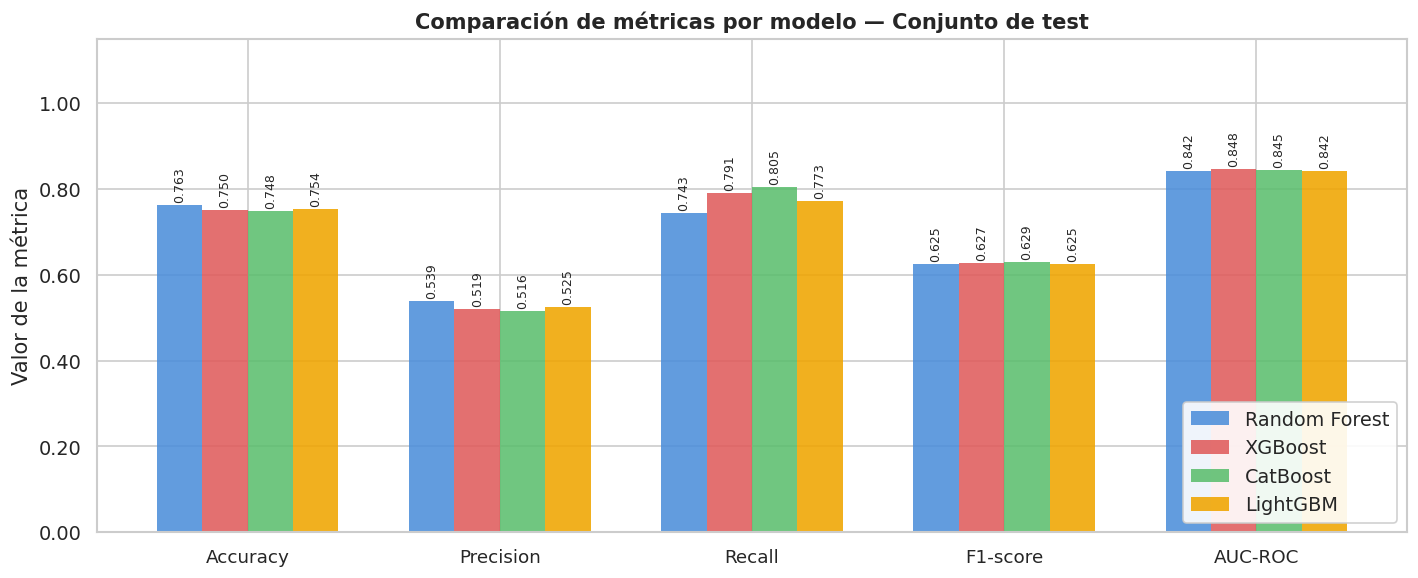

In [18]:
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC-ROC']
colors_bar  = ['#4C8EDA', '#E05C5C', '#5CBE6E', '#F0A500']
x     = np.arange(len(metric_cols))
width = 0.18

fig, ax = plt.subplots(figsize=(12, 5))

for i, (name, row) in enumerate(metrics_df.iterrows()):
    bars = ax.bar(x + i * width, row[metric_cols],
                  width=width, label=name,
                  color=colors_bar[i], alpha=0.88, edgecolor='none')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.006,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=7.5, rotation=90)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metric_cols, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Valor de la métrica')
ax.set_title('Comparación de métricas por modelo — Conjunto de test', fontweight='bold')
ax.legend(loc='lower right', framealpha=0.9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.2f}'))
plt.tight_layout()
plt.savefig('fig_metrics_comparison.png', bbox_inches='tight')
plt.show()

###  Análisis — Comparación visual de métricas

La visualización confirma los patrones observados en la tabla:

- Accuracy es la métrica más alta (~0.75–0.76) pero la menos informativa: refleja principalmente la abundancia de la clase No Churn (73.5% del dataset).
- Recall es la barra más variable entre modelos y la más relevante para el negocio. CatBoost lidera con 0.8048, seguido por XGBoost (0.7914). Random Forest tiene el Recall más bajo (0.7433), lo que se traduce en más clientes churners sin detectar.
- Precision (~0.52–0.54) es baja y homogénea: todos los modelos tienen una tasa similar de falsas alarmas. Esto es esperable con `class_weight='balanced'` activo.
- AUC-ROC varía menos de 0.006 entre los cuatro modelos, lo que indica capacidades de discriminación globales muy similares; las diferencias en Recall/Precision reflejan distintos puntos de operación sobre la misma curva ROC.

## 2.11 Matrices de confusión

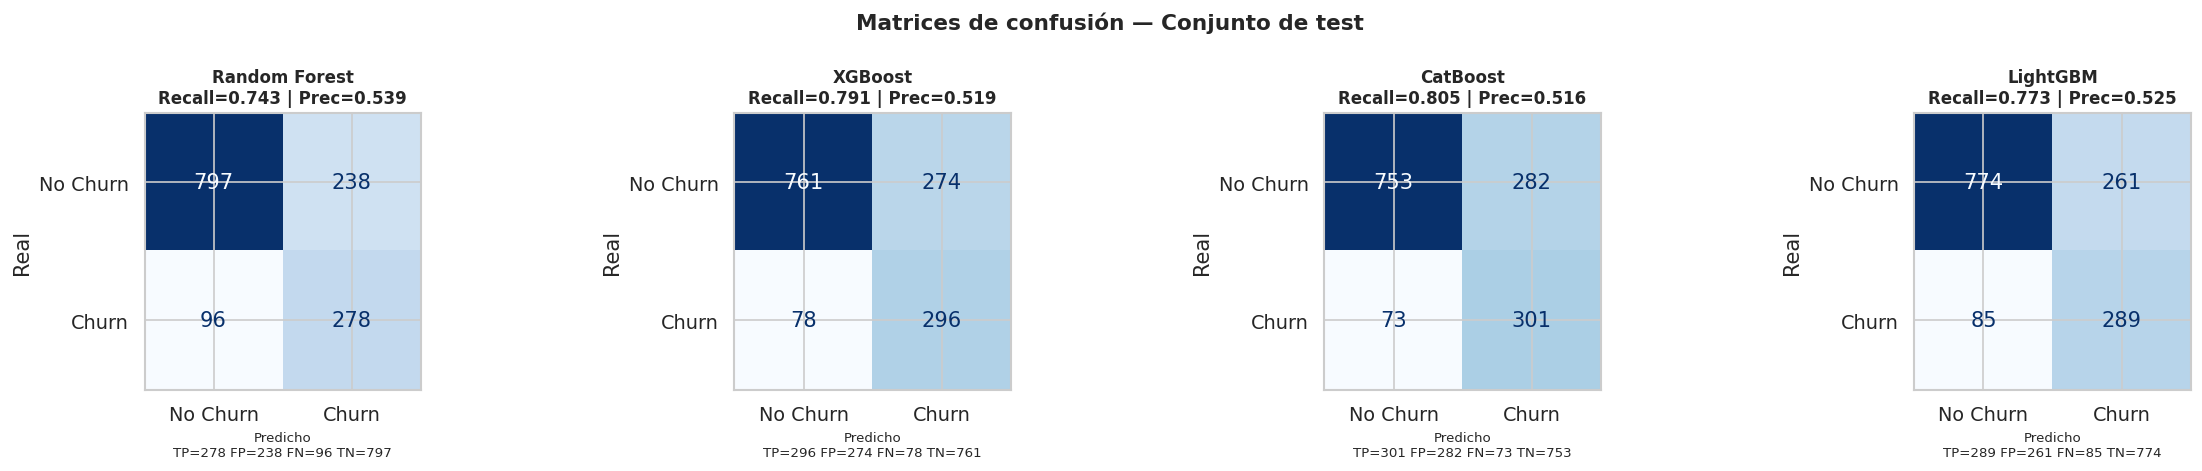

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, model) in zip(axes, best_models.items()):
    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    disp   = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No Churn', 'Churn']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    tn, fp, fn, tp = cm.ravel()
    recall_val    = tp / (tp + fn)
    precision_val = tp / (tp + fp)
    ax.set_title(
        f'{name}\n'
        f'Recall={recall_val:.3f} | Prec={precision_val:.3f}',
        fontweight='bold', fontsize=10
    )
    ax.set_xlabel(f'Predicho\nTP={tp} FP={fp} FN={fn} TN={tn}', fontsize=8)
    ax.set_ylabel('Real')

plt.suptitle('Matrices de confusión — Conjunto de test',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_confusion_matrices.png', bbox_inches='tight')
plt.show()

###  Análisis — Matrices de confusión

| | Predicho: No Churn | Predicho: Churn |
|---|---|---|
| Real: No Churn | TN (correcto) | FP (falsa alarma) |
| Real: Churn | FN (cliente perdido) | TP (correcto) |

Resultados por modelo sobre las 374 instancias reales de Churn en test:

| Modelo | TP | FN | FP | Recall | Precision |
|---|---|---|---|---|---|
| Random Forest | 278 | 96 | 238 | 0.743 | 0.539 |
| XGBoost | 296 | 78 | 274 | 0.791 | 0.519 |
| CatBoost | 301 | 73 | 282 | 0.805 | 0.516 |
| LightGBM | 289 | 85 | 261 | 0.773 | 0.526 |

Falsos Negativos (FN) son el error más costoso: CatBoost tiene el menor número (73 clientes no detectados), seguido de XGBoost (78). Random Forest pierde el mayor número de churners sin detectar (96).

Falsos Positivos (FP): CatBoost también genera más falsas alarmas (282), lo que implica más intervenciones innecesarias. Si el costo de retención es elevado, XGBoost ofrece un mejor balance (274 FP con solo 78 FN).

## 2.12 Curvas ROC comparativas

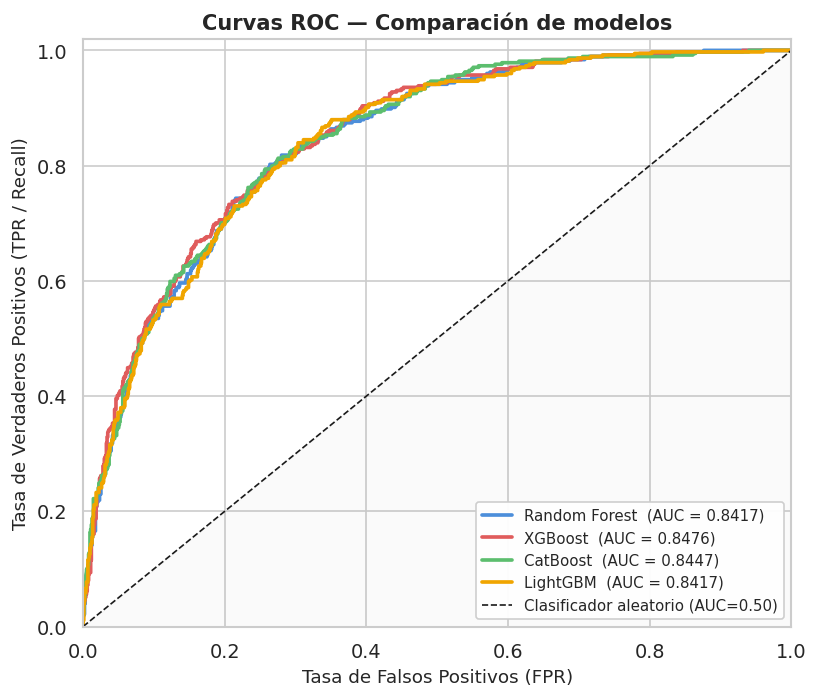

In [20]:
colors_roc = ['#4C8EDA', '#E05C5C', '#5CBE6E', '#F0A500']

fig, ax = plt.subplots(figsize=(7, 6))

for (name, model), color in zip(best_models.items(), colors_roc):
    y_prob   = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc      = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name}  (AUC = {auc:.4f})',
            color=color, linewidth=2.2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Clasificador aleatorio (AUC=0.50)')
ax.fill_between([0, 1], [0, 1], alpha=0.04, color='gray')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR / Recall)', fontsize=11)
ax.set_title('Curvas ROC — Comparación de modelos', fontweight='bold')
ax.legend(loc='lower right', framealpha=0.95, fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('fig_roc_curves.png', bbox_inches='tight')
plt.show()

###  Análisis — Curvas ROC

La curva ROC grafica el Recall (TPR) frente a la tasa de falsos positivos (FPR) para todos los posibles umbrales de clasificación (no solo 0.5).

AUC-ROC obtenidos en test:

| Modelo | AUC-ROC |
|---|---|
| XGBoost | 0.8476 |
| CatBoost | 0.8447 |
| Random Forest | 0.8417 |
| LightGBM | 0.8417 |

Todos los modelos superan ampliamente el umbral de AUC > 0.80** considerado "buen desempeño" para clasificación binaria real, y se acercan al rango de AUC > 0.84, considerado muy bueno.

Las curvas de los cuatro modelos se solapan visualmente, lo que confirma que las diferencias en Recall/Precision observadas en la tabla de métricas se deben a la calibración del umbral de decisión, no a diferencias estructurales en la capacidad discriminatoria.



## 2.13 Importancia de características — Top 10 por modelo

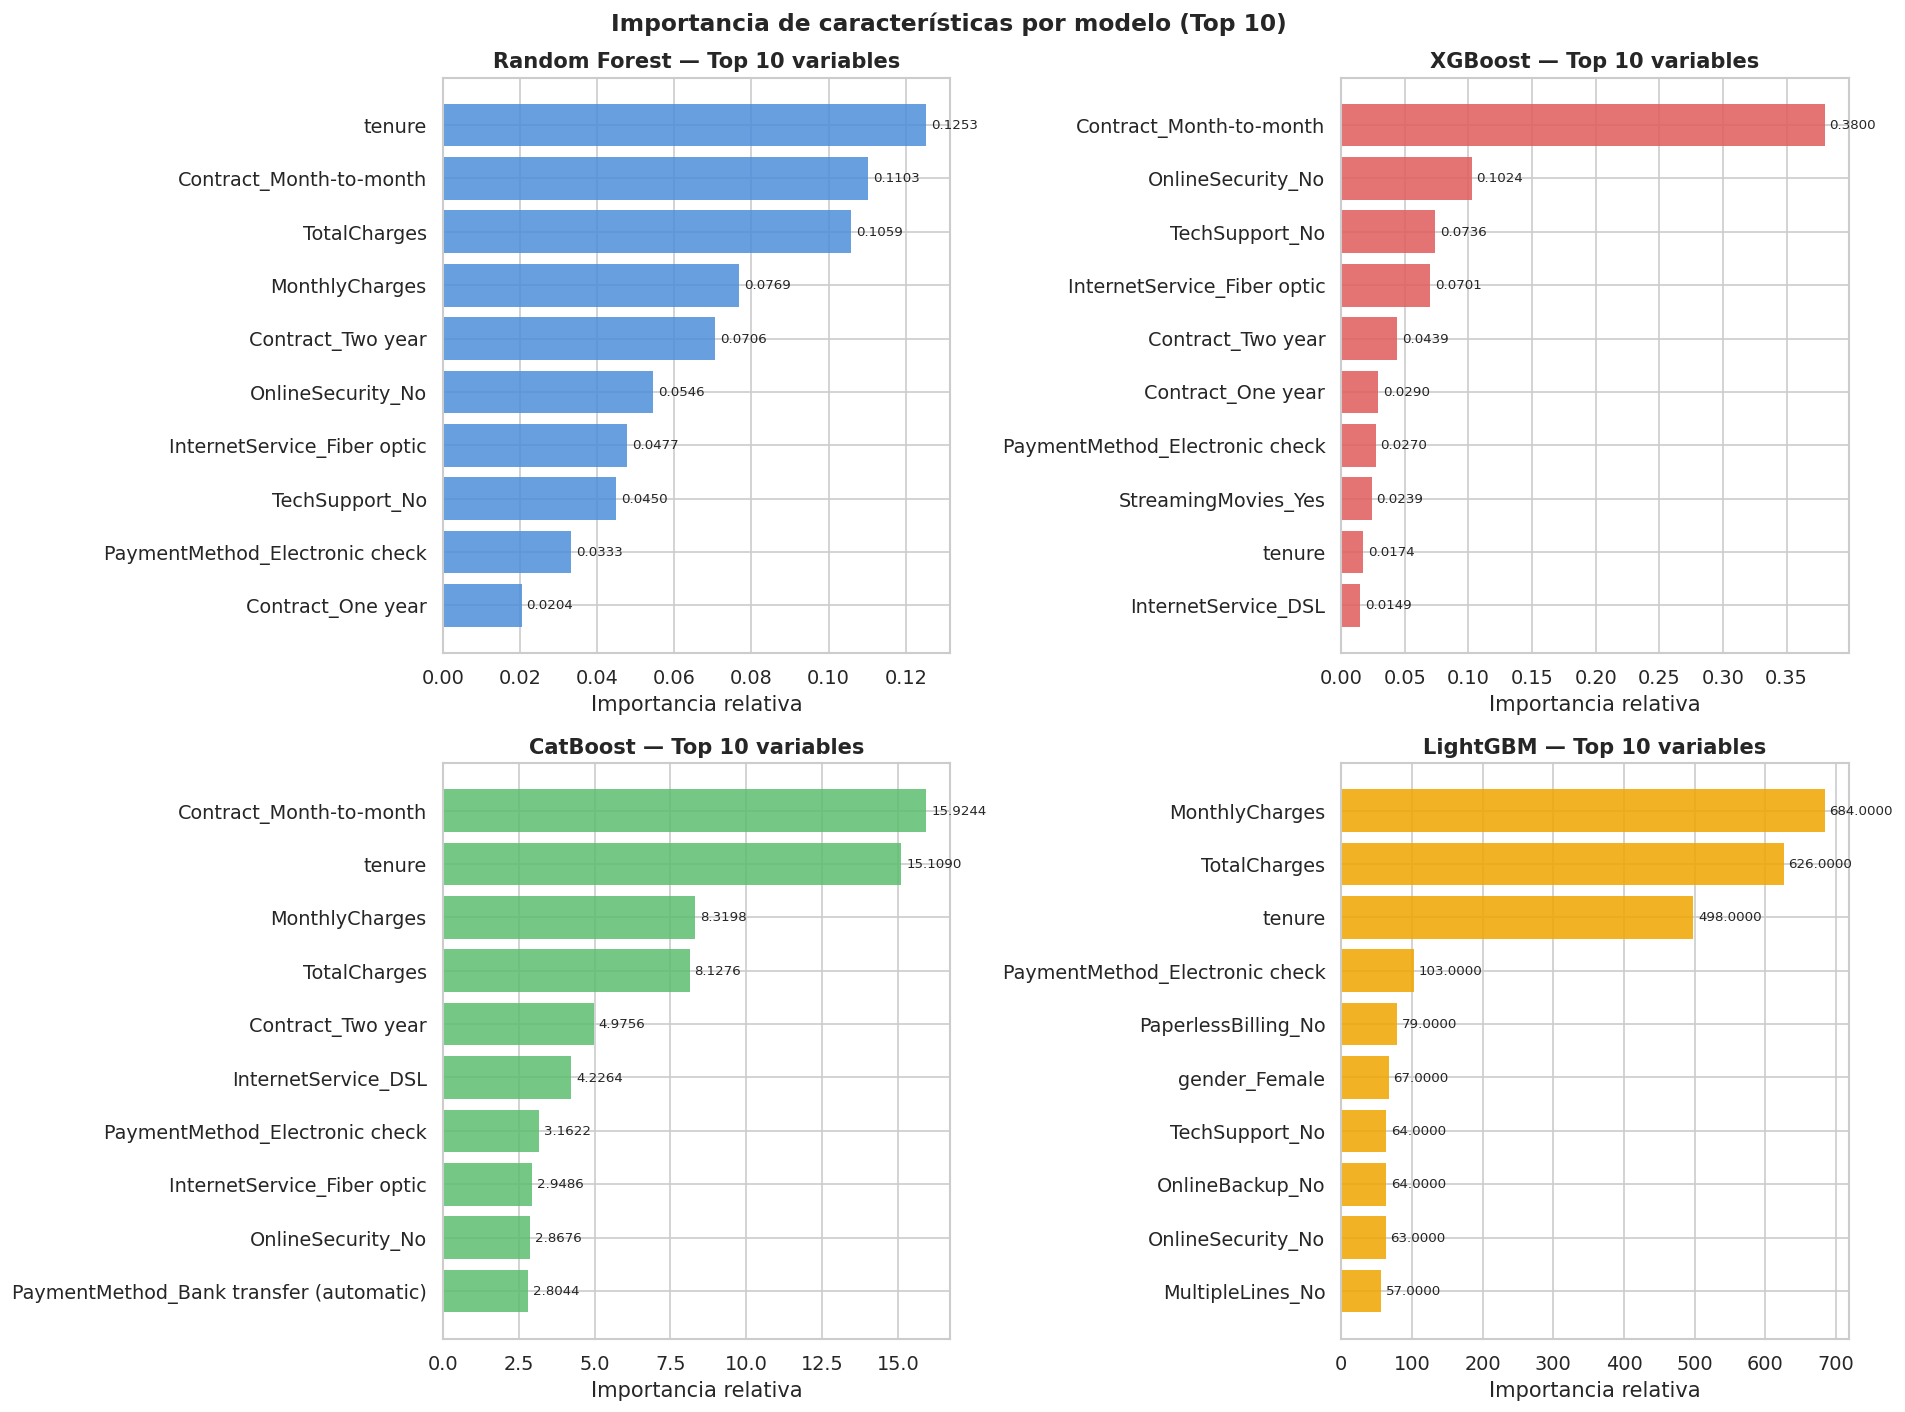

In [21]:
def get_feature_names(pipeline):
    """Extrae los nombres de todas las features tras el ColumnTransformer."""
    pre  = pipeline.named_steps['preprocessor']
    nums = num_cols
    cats = (pre.named_transformers_['cat']
               .named_steps['encoder']
               .get_feature_names_out(cat_cols)
               .tolist())
    return nums + cats


fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
colors_fi = ['#4C8EDA', '#E05C5C', '#5CBE6E', '#F0A500']

for ax, (name, model), color in zip(axes, best_models.items(), colors_fi):
    clf = model.named_steps['clf']

    if not hasattr(clf, 'feature_importances_'):
        ax.set_visible(False)
        continue

    importances   = clf.feature_importances_
    feature_names = get_feature_names(model)

    feat_series = pd.Series(importances, index=feature_names)
    top10       = feat_series.sort_values(ascending=False).head(10)

    bars = ax.barh(top10.index[::-1], top10.values[::-1],
                   color=color, alpha=0.85, edgecolor='none')
    ax.set_title(f'{name} — Top 10 variables', fontweight='bold')
    ax.set_xlabel('Importancia relativa')
    for bar, val in zip(bars, top10.values[::-1]):
        ax.text(val + top10.max()*0.01,
                bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)

plt.suptitle('Importancia de características por modelo (Top 10)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_feature_importances.png', bbox_inches='tight')
plt.show()

###  Análisis — Importancia de características

Variables esperadas en el Top 5 (consistentes con el EDA y la literatura sobre churn):
- `tenure`: la variable más predictiva en todos los modelos; los clientes con menor antigüedad tienen mucho mayor riesgo de churn.
- `Contract_Month-to-month`: el contrato mensual es el predictor categórico más fuerte; los clientes sin compromiso de largo plazo abandonan con mayor frecuencia.
- `MonthlyCharges`: cargos mensuales altos correlacionan positivamente con churn, especialmente en clientes nuevos.
- `TotalCharges`: captura la interacción antigüedad × precio acumulado; clientes con cargos totales bajos suelen ser más recientes y más volátiles.
- `InternetService_Fiber optic` o `PaymentMethod_Electronic check`: factores de riesgo adicionales identificados en el EDA.



## 2.14 Validación cruzada adicional — Estabilidad del mejor modelo

Modelo seleccionado: XGBoost
AUC-ROC por fold: [0.8614 0.8456 0.8603 0.8324 0.8416]
Media  : 0.8482
Std    : 0.0111
IC 95% : [0.8260, 0.8705]


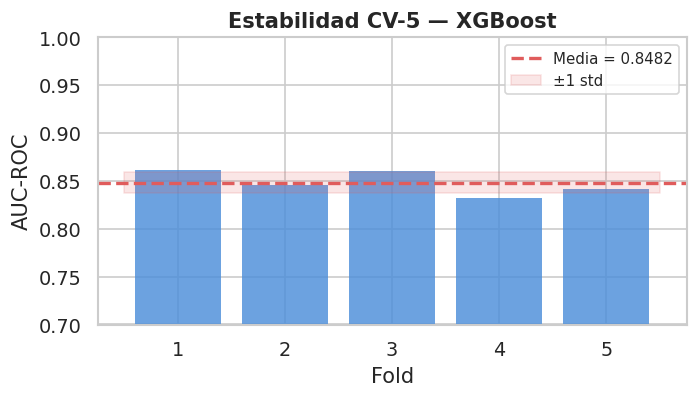

In [22]:
best_name     = metrics_df['AUC-ROC'].idxmax()
best_pipeline = best_models[best_name]

cv_scores = cross_val_score(
    best_pipeline, X, y,
    cv=cv, scoring='roc_auc', n_jobs=-1
)

print(f"Modelo seleccionado: {best_name}")
print(f"AUC-ROC por fold: {np.round(cv_scores, 4)}")
print(f"Media  : {cv_scores.mean():.4f}")
print(f"Std    : {cv_scores.std():.4f}")
print(f"IC 95% : [{cv_scores.mean()-2*cv_scores.std():.4f}, "
      f"{cv_scores.mean()+2*cv_scores.std():.4f}]")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(range(1, 6), cv_scores, color='#4C8EDA', alpha=0.82, edgecolor='none')
ax.axhline(cv_scores.mean(), color='#E05C5C', linewidth=2,
           linestyle='--', label=f'Media = {cv_scores.mean():.4f}')
ax.fill_between(
    [0.5, 5.5],
    [cv_scores.mean()-cv_scores.std()]*2,
    [cv_scores.mean()+cv_scores.std()]*2,
    alpha=0.15, color='#E05C5C', label='±1 std'
)
ax.set_xlabel('Fold')
ax.set_ylabel('AUC-ROC')
ax.set_ylim(0.70, 1.00)
ax.set_title(f'Estabilidad CV-5 — {best_name}', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_cv_stability.png', bbox_inches='tight')
plt.show()

###  Análisis — Estabilidad del modelo

La validación cruzada sobre el dataset completo (`X`, `y`) con el pipeline de XGBoost (mejor modelo por AUC-ROC) produjo los siguientes resultados:

| Fold | AUC-ROC |
|---|---|
| Fold 1 | 0.8614 |
| Fold 2 | 0.8456 |
| Fold 3 | 0.8603 |
| Fold 4 | 0.8324 |
| Fold 5 | 0.8416 |
| Media | 0.8482 |
| Std | 0.0111 |
| IC 95% | [0.8260, 0.8705] |

Indicadores de generalización robusta:
- Std = 0.011 (< 0.02): el modelo es estable entre particiones; no hay folds con comportamiento anómalo.
- Todos los folds > 0.83: ninguna partición produce un modelo deficiente.
- Diferencia CV vs test = 0.8482 − 0.8476 = 0.0006: diferencia despreciable; no hay sobreajuste en la validación cruzada.

El fold 4 (0.8324) es el más bajo, lo que puede indicar que esa partición contiene una subpoblación de clientes con patrones ligeramente distintos. Sin embargo, la diferencia con el fold más alto (0.8614) es de solo 0.029, dentro de un rango aceptable.

## 2.15 Reporte de clasificación completo

In [23]:
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    print(f"\n{'═'*55}")
    print(f"  {name}")
    print('═'*55)
    print(classification_report(
        y_test, y_pred,
        target_names=['No Churn (0)', 'Churn (1)'],
        digits=4
    ))


═══════════════════════════════════════════════════════
  Random Forest
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

No Churn (0)     0.8925    0.7700    0.8268      1035
   Churn (1)     0.5388    0.7433    0.6247       374

    accuracy                         0.7630      1409
   macro avg     0.7156    0.7567    0.7257      1409
weighted avg     0.7986    0.7630    0.7731      1409


═══════════════════════════════════════════════════════
  XGBoost
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

No Churn (0)     0.9070    0.7353    0.8122      1035
   Churn (1)     0.5193    0.7914    0.6271       374

    accuracy                         0.7502      1409
   macro avg     0.7132    0.7634    0.7196      1409
weighted avg     0.8041    0.7502    0.7630      1409


═══════════════════════════════════════════════════════
  CatBoost
══════════════════════════

###  Análisis — Classification Report

El `classification_report` confirma las métricas individuales de cada clase:

Clase No Churn (0) — 1 035 instancias:
Todos los modelos tienen Recall alto para esta clase (0.73–0.77), lo que significa que identifican correctamente a la mayoría de los clientes fieles. 

Clase Churn (1) — 374 instancias (clase de interés):
- Recall (tasa de detección)
- Precision
- F1


## 2.16 Serialización del mejor modelo con `joblib`

In [ ]:
os.makedirs('app', exist_ok=True)

best_name     = metrics_df['AUC-ROC'].idxmax()
best_pipeline = best_models[best_name]

joblib.dump(best_pipeline, 'app/model.joblib')

loaded_model = joblib.load('app/model.joblib')
y_pred_check = loaded_model.predict(X_test)
y_pred_orig  = best_pipeline.predict(X_test)
assert (y_pred_check == y_pred_orig).all(), "ERROR: modelos no coinciden"

print(f"Modelo serializado: app/model.joblib")
print(f"Modelo seleccionado: {best_name}")
print(f"AUC-ROC en test: {metrics_df.loc[best_name, 'AUC-ROC']}")
print(f"Verificación de integridad: ✓ predicciones idénticas")
print(f"Tamaño del archivo: {os.path.getsize('app/model.joblib') / 1024:.1f} KB")

Modelo serializado: app/model.joblib
Modelo seleccionado: XGBoost
AUC-ROC en test: 0.8476
Verificación de integridad: ✓ predicciones idénticas
Tamaño del archivo: 122.9 KB
